# Analyse de la qualité de l’air – Dashboard interactif R Shiny
Ce projet vise à concevoir un dashboard interactif sous R Shiny, à partir d’un jeu de données réel sur la qualité de l’air (AAP_2022_city_v9.csv). L’objectif est double : nettoyer, transformer et analyser les données de manière rigoureuse, puis proposer une visualisation dynamique facilitant l’exploration des polluants atmosphériques les plus nocifs (PM₂.₅, PM₁.₀, NO₂).

Contexte métier et constats clés
L’analyse révèle que :

Les PM₂.₅ (particules fines < 2,5 µm) sont responsables de 84 % des décès liés à la pollution de l’air, dont 70 à 75 % sont attribuables aux PM₁.₀, encore plus fines et dangereuses.

Le NO₂, issu majoritairement du trafic routier et des activités industrielles, représente 14 % des décès.

Les principales sources d’émission sont : la combustion résidentielle, les transports, l’industrie, l’agriculture et la production d’énergie.



## Orientation stratégique du projet

Nous avons axé la thématique centrale de notre analyse autour de la question suivante :

**"Comment la pollution de l’air a-t-elle évolué dans les pays de la région européenne (zone géographique retenue?) entre 2015 et 2019 ?"**

L'objectif est de suivre les niveaux de concentration des principaux polluants atmosphériques — **PM2.5**, **PM10** et **NO2** — sur une période de cinq ans, et ce, à l’échelle des **pays et des villes** de la région européenne.

### Questions clés auxquelles nous allons tenter de répondre :

- Les niveaux de pollution ont-ils diminué dans certaines régions ?
- Quels pays ont enregistré une amélioration ou, au contraire, une dégradation notable de la qualité de l'air ?
- Les évolutions observées sont-elles cohérentes avec les politiques environnementales mises en place par les pays concernés ?



## Chargement des librairies 

In [94]:
install.packages("plotly")
install.packages("corrplot")
install.packages("janitor")
install.packages("Amelia")

Warning message:
"le package 'plotly' est en cours d'utilisation et ne sera pas installé"
Warning message:
"le package 'corrplot' est en cours d'utilisation et ne sera pas installé"
Installation du package dans 'C:/Users/Windows/AppData/Local/R/win-library/4.5'
(car 'lib' n'est pas spécifié)



le package 'janitor' a été décompressé et les sommes MD5 ont été vérifiées avec succés

Les packages binaires téléchargés sont dans
	C:\Users\Windows\AppData\Local\Temp\RtmpIhgWWa\downloaded_packages


Warning message:
"le package 'Amelia' est en cours d'utilisation et ne sera pas installé"


In [96]:
library("corrplot")
library("dplyr")
library("tidyr")
library("ggplot2")  # Pour ggplot()
library("stringr")  # Pour str_to_title()
library("Amelia")
library(plotly)

## 1. Exploration initiale du fichier

# Informations sur la base de données initiale (Document officiel de l'OMS)

### Base de données qualité de l’air - OMS (2022)

- **Source :** Base de données OMS, avril 2022  
  [lien](https://www.who.int/data/gho/data/themes/air-pollution/who-air-quality-database)

- **Polluants :** PM10, PM2.5, NO₂ (concentrations annuelles moyennes en μg/m³)

- **Données :**  
  Rapports officiels, réseaux régionaux (EEA, Clean Air for Asia, AirNow), projets de recherche, articles scientifiques.  
  Couverture minimale : 50 % de l’année (exceptions possibles).  
  Période : 2010–2019, quelques données 2020.

- **Méthode :**  
  Mesures en zones urbaines représentatives, exclusion des "hot spots" industriels sauf intégrés dans les moyennes urbaines.

- **Limites :**  
  Variabilité des méthodes, couverture inégale, biais saisonnier possible, données surtout urbaines.

- **Valeurs guides OMS :**  
  PM10 : 15 μg/m³ | PM2.5 : 5 μg/m³ | NO₂ : 10 μg/m³  

In [ ]:
Chargement des données

In [97]:
# chargement des données
data <- read.csv("C:/Users/Windows/Desktop/projets/1a/R/Projet_R_2_Oms/data/AAP_2022_city_v9.csv")
str(data)

'data.frame':	32191 obs. of  15 variables:
 $ WHO.Region                            : chr  "Eastern Mediterranean Region" "European Region" "European Region" "European Region" ...
 $ ISO3                                  : chr  "AFG" "ALB" "ALB" "ALB" ...
 $ WHO.Country.Name                      : chr  "Afghanistan" "Albania" "Albania" "Albania" ...
 $ City.or.Locality                      : chr  "Kabul" "Durres" "Durres" "Elbasan" ...
 $ Measurement.Year                      : int  2019 2015 2016 2015 2016 2017 2015 2016 2014 2015 ...
 $ PM2.5..μg.m3.                         : chr  "119,77" "" "14,32" "" ...
 $ PM10..μg.m3.                          : chr  "" "17,65" "24,56" "" ...
 $ NO2..μg.m3.                           : chr  "" "26,63" "24,78" "23,96" ...
 $ PM25.temporal.coverage....            : chr  "18" "" "" "" ...
 $ PM10.temporal.coverage....            : chr  "" "" "" "" ...
 $ NO2.temporal.coverage....             : chr  "" "83,96118721" "87,93260474" "97,85388128" ...
 $ 

## Description du dataset

Le jeu de données `AAP_2022_city_v9.csv` contient **5 554 observations** réparties sur **15 variables**. Il regroupe des mesures de la qualité de l’air dans plusieurs **villes du monde**, sur plusieurs années, avec un focus sur les polluants **PM₂.₅**, **PM₁₀** et **NO₂**.

### Dictionnaire des variables

| Variable                     | Type   | Description                                                                 |
|-----------------------------|--------|-----------------------------------------------------------------------------|
| `region`                    | chr    | Région géographique (ex. : "European Region").                              |
| `code_iso3`                 | chr    | Code pays ISO à 3 lettres (ex. : "FRA", "USA").                             |
| `country_name`              | chr    | Nom du pays.                                                                |
| `city`                      | chr    | Nom de la ville où les mesures ont été prises.                              |
| `measure_year`             | int    | Année de la mesure.                                                        |
| `measure_pm25_ug_m3`        | num    | Concentration annuelle moyenne de PM₂.₅ (µg/m³).                            |
| `measure_pm10_ug_m3`        | num    | Concentration annuelle moyenne de PM₁₀ (µg/m³).                             |
| `measure_no2_ug_m3`         | num    | Concentration annuelle moyenne de NO₂ (µg/m³).                              |
| `pm25_temporal_coverage`    | num    | Couverture temporelle des mesures PM₂.₅ (en % de l'année).                 |
| `pm10_temporal_coverage`    | num    | Couverture temporelle des mesures PM₁₀ (en % de l'année).                 |
| `no2_temporal_coverage`     | num    | Couverture temporelle des mesures NO₂ (en % de l'année).                  |
| `source`                    | chr    | Source des données (ex. : "European Environment Agency").                   |
| `monitoring_station_number`| chr    | Identifiant de la station de mesure (souvent manquant).                     |
| `database_version`          | int    | Version de la base de données (ex. : 2022).                                 |
| `status`                    | logi   | Statut ou indicateur binaire (informations incomplètes / souvent manquant). |


### Exploration du dataset

In [20]:
summary(data)

  WHO.Region            ISO3           WHO.Country.Name   City.or.Locality  
 Length:32191       Length:32191       Length:32191       Length:32191      
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
 Measurement.Year PM2.5..μg.m3.      PM10..μg.m3.       NO2..μg.m3.       
 Min.   :2000     Length:32191       Length:32191       Length:32191      
 1st Qu.:2014     Class :character   Class :character   Class :character  
 Median :2016     Mode  :character   Mode  :character   Mode  :character  
 Mean   :2016                                                             
 3rd Qu.:2018                                                             
 Max.   :20

### Statistiques descriptives des variables numériques

Ce jeu de données comprend des mesures de pollution de l'air collectées entre 2017 et 2019 dans plusieurs villes européennes. Voici un résumé statistique des variables numériques :


#### Métadonnées

- `database_version` : Toutes les valeurs sont identiques (2022).
- `status` : Colonne logique entièrement manquante (`NA` pour les 5554 observations).

---

Malgré la dispersion apparente de certaines valeurs (notamment pour les particules PM₁₀ et NO₂), et compte tenu de la nature scientifique de notre sujet ainsi que de la fiabilité reconnue de la source (European Environment Agency), nous avons estimé qu’une recherche systématique des valeurs aberrantes aurait été contre-productive. Nous avons donc conservé l’ensemble des mesures telles quelles, en considérant qu’elles reflètent des variations environnementales réelles.


## Statistiques Descriptives & Corrélations

### Analyse des valeurs manquantes

### Etude du pourcentage de valeurs manquantes


 FALSE   TRUE 
271423  82678 

[1] 23.34871

region              country_name                      city 
               0.00000000                0.00000000                0.00000000 
             measure_year        measure_pm25_μg_m3        measure_pm10_μg_m3 
               0.00000000               53.25401510               34.42577118 
        measure_no2_μg_m3                    source monitoring_station_number 
              31.03662514                0.01553229               72.64142152 
       measure_PM10_μg_m3         measure_NO2_μg_m3 
              34.42577118               31.03662514

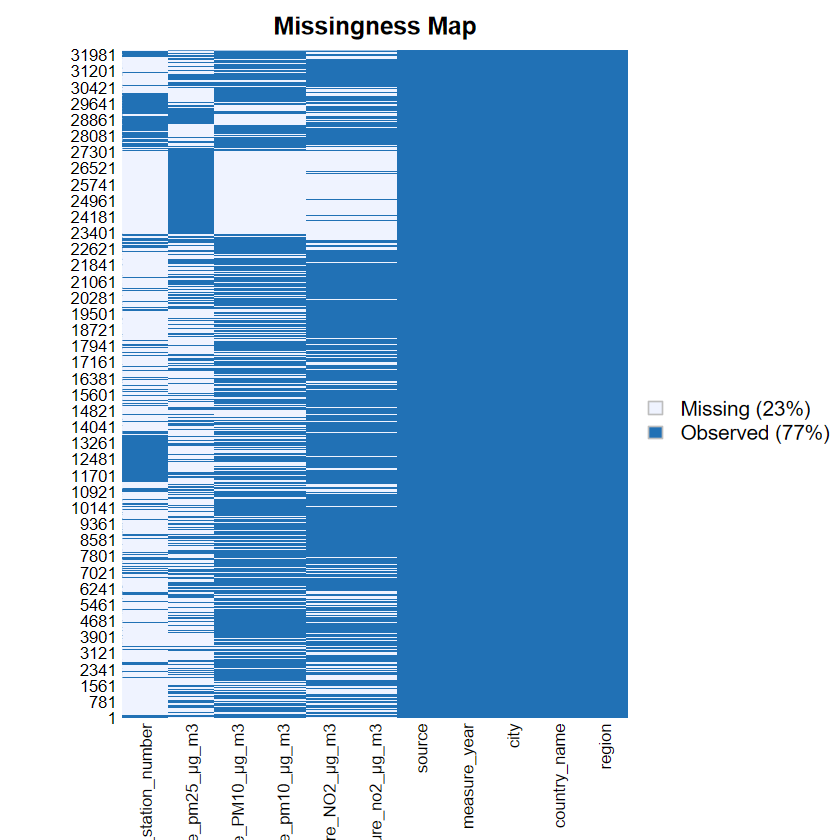

In [88]:
table(is.na(data))

missing_data <- sum(is.na(data))  / (nrow(data)* ncol(data))*100
missing_data

col_missing <- colSums(is.na(data))/ nrow(data) * 100
col_missing

missmap(data)

**État de complétude du dataset original**

L'analyse globale du dataset révèle un taux de données manquantes de **17,4%** sur l'ensemble des observations (61 605 valeurs manquantes sur 354 101 au total), avec des disparités importantes selon les variables mesurées.

**Indicateurs critiques :**
- **PM2.5** : 53,3% de données manquantes - le polluant le moins documenté
- **Numéros de stations de monitoring** : 72,6% d'absence - problème majeur d'identification des capteurs
- **PM10 et NO2 (colonnes dupliquées)** : 34,4% et 31,1% respectivement

**Points positifs :** Les variables géographiques (région, pays, ville) et temporelles (année) sont complètes à 100%, garantissant une localisation et un référencement temporel fiables pour toutes les observations.

Ces lacunes confirment la nécessité de notre stratégie de filtrage pour ne conserver que les données exploitables dans nos analyses statistiques.

### Etude des valeurs manquantes en % et par région

## 2.  Nettoyage et prétraitement 

## Prétraitement de données

### Supression des colonnes inutiles

In [29]:
data <- data %>% 
  dplyr::select(-PM25.temporal.coverage...., 
               -PM10.temporal.coverage....,
               -NO2.temporal.coverage....,
               -Version.of.the.database,
               -ISO3,
               -Status)

Nettoyage du dataset : suppression des colonnes non pertinentes

Ces colonnes ont été supprimées car elles n'apportent aucune valeur ajoutée à notre analyse de la qualité de l'air : les informations de couverture temporelle, de version de base de données, de codes ISO3 et de statut sont soit redondantes avec nos données existantes, soit non exploitables pour nos objectifs d'étude des corrélations entre polluants.

Cette étape d'allégement du dataset améliore les performances de traitement et la lisibilité des résultats en ne conservant que les variables directement utiles à notre analyse.

### Renommage des colonnes

In [98]:
names(data) <- c(
  "region", "country_name", "city", "measure_year",
  "measure_pm25_μg_m3", "measure_pm10_μg_m3", "measure_no2_μg_m3",
  "source", "monitoring_station_number"
)

### Conversions

In [31]:
# Conversion des colonnes de mesures (format texte avec virgule) en numériques
data$measure_pm25_μg_m3 <- as.numeric(gsub(",", ".", data$measure_pm25_μg_m3))
data$measure_PM10_μg_m3 <- as.numeric(gsub(",", ".", data$measure_pm10_μg_m3))
data$measure_NO2_μg_m3  <- as.numeric(gsub(",", ".", data$measure_no2_μg_m3))

Ce code convertit les colonnes de mesures de pollution de format texte vers format numérique en remplaçant les virgules par des points comme séparateurs décimaux. Cette transformation est nécessaire pour permettre les calculs statistiques sur les valeurs de concentration des polluants (PM2.5, PM10 et NO2).RéessayerClaude peut faire des erreurs. Assurez-vous de vérifier ses réponses.

### Diagnostic des valeurs manquantes par zone géographique

In [32]:
# ========= PROUVER LES LA FORTE PROPORTION DE VALEUR MANQUANTES PAR REGION ====

regions <- unique(data$region)
# Initialiser une liste vide pour stocker les résultats
missing_by_region <- list()

# Boucle sur chaque région
for (reg in regions) {
  # Filtrer les données pour la région en cours
  data_region <- subset(data, region == reg)
  
  # Calculer le pourcentage de valeurs manquantes par colonne
  col_missing <- colSums(is.na(data_region)) / nrow(data_region) * 100
  
  # Stocker le résultat dans la liste avec le nom de la région
  missing_by_region[[reg]] <- col_missing
}

# accéder aux valeurs manquantes pour la région "Eastern Mediterranean Region"
print("Eastern Mediterranean Region")
missing_by_region[["Eastern Mediterranean Region"]]

# accéder aux valeurs manquantes pour la région "Western Pacific Region"
print("Western Pacific Region")
missing_by_region[["Western Pacific Region"]]

# accéder aux valeurs manquantes pour la région "European Region"
missing_by_region[["European Region"]]

# accéder aux valeurs manquantes pour la région "South East Asia Region"
print("South East Asia Region")
missing_by_region[["South East Asia Region"]]

# accéder aux valeurs manquantes pour la région "Region of the Americas"
print("Region of the Americas")
missing_by_region[["Region of the Americas"]]

# accéder aux valeurs manquantes pour la région "African Region"
print("African Region")
missing_by_region[["African Region"]]

[1] "Eastern Mediterranean Region"


region              country_name                      city 
                 0.000000                  0.000000                  0.000000 
             measure_year        measure_pm25_μg_m3        measure_pm10_μg_m3 
                 0.000000                 49.543379                 34.246575 
        measure_no2_μg_m3                    source monitoring_station_number 
                65.981735                  1.141553                 55.707763 
       measure_PM10_μg_m3         measure_NO2_μg_m3 
                34.246575                 65.981735

[1] "Western Pacific Region"


region              country_name                      city 
                 0.000000                  0.000000                  0.000000 
             measure_year        measure_pm25_μg_m3        measure_pm10_μg_m3 
                 0.000000                  7.503126                 85.473114 
        measure_no2_μg_m3                    source monitoring_station_number 
                87.161317                  0.000000                 91.288037 
       measure_PM10_μg_m3         measure_NO2_μg_m3 
                85.473114                 87.161317

region              country_name                      city 
                  0.00000                   0.00000                   0.00000 
             measure_year        measure_pm25_μg_m3        measure_pm10_μg_m3 
                  0.00000                  62.59117                  19.78119 
        measure_no2_μg_m3                    source monitoring_station_number 
                 16.43012                   0.00000                  80.04632 
       measure_PM10_μg_m3         measure_NO2_μg_m3 
                 19.78119                  16.43012

...

region              country_name                      city 
                 0.000000                  0.000000                  0.000000 
             measure_year        measure_pm25_μg_m3        measure_pm10_μg_m3 
                 0.000000                 78.003182                 43.556086 
        measure_no2_μg_m3                    source monitoring_station_number 
                12.092283                  0.000000                  3.341289 
       measure_PM10_μg_m3         measure_NO2_μg_m3 
                43.556086                 12.092283

[1] "Region of the Americas"


region              country_name                      city 
                  0.00000                   0.00000                   0.00000 
             measure_year        measure_pm25_μg_m3        measure_pm10_μg_m3 
                  0.00000                  46.42406                  42.73439 
        measure_no2_μg_m3                    source monitoring_station_number 
                 45.86808                   0.00000                  61.18271 
       measure_PM10_μg_m3         measure_NO2_μg_m3 
                 42.73439                  45.86808

[1] "African Region"


region              country_name                      city 
                 0.000000                  0.000000                  0.000000 
             measure_year        measure_pm25_μg_m3        measure_pm10_μg_m3 
                 0.000000                 34.554974                 16.230366 
        measure_no2_μg_m3                    source monitoring_station_number 
                35.078534                  0.000000                  5.759162 
       measure_PM10_μg_m3         measure_NO2_μg_m3 
                16.230366                 35.078534

### Analyse des données manquantes par région géographique

L'examen des données manquantes révèle des taux de défaillance considérables dans toutes les régions du monde, avec des pourcentages variant de 12% à 91% selon les polluants et les zones géographiques. Cette situation généralisée rend impossible l'étude approfondie d'une zone spécifique.

**Causes identifiées :** L'absence massive de données, malgré l'existence d'un grand nombre de capteurs référencés, suggère trois problématiques principales : défaillances techniques des équipements de mesure, interruptions dans les protocoles de relevé, ou défauts de communication/transmission des données collectées.

**Impact sur l'analyse :** Ces lacunes compromettent la fiabilité des analyses statistiques et limitent notre capacité à établir des comparaisons robustes entre régions ou à identifier des tendances géographiques significatives.

Recommandation

Il est urgent de standardiser et renforcer les systèmes de surveillance de la qualité de l'air à l'échelle mondiale, en priorisant la maintenance préventive des équipements, la formation des opérateurs et la mise en place de protocoles de transmission automatisée pour garantir la continuité et la fiabilité des données environnementales.

### Filtrage des zones à étudier

Choix de l'année 2019 pour l'analyse des corrélations
Nous avons sélectionné l'année 2019 pour notre étude des corrélations entre polluants atmosphériques (PM10, NO2 et PM2.5) car c'est la seule année qui fournit à la fois l'ensemble des zones géographiques et un maximum de pays par zone avec des mesures complètes des trois polluants.
Cette approche garantit une couverture globale optimale et une robustesse statistique maximale pour nos analyses de corrélation à l'échelle internationale.

In [33]:
# ----- Filtrage du dataset "data" - année 2019 : Les pays avec avec des mesures complètes ----

# Étape 1: Garder uniquement l'année 2019
data_2019 <- data[data$measure_year == 2019, ]

# Étape 2: Garder seulement les lignes où PM10, NO2 et PM2.5 ne sont pas vides
data_2019_complet <- data_2019[!is.na(data_2019$measure_pm10_μg_m3) & 
                                 !is.na(data_2019$measure_no2_μg_m3) & 
                                 !is.na(data_2019$measure_pm25_μg_m3), ]

print("Régions présentes dans les données 2019 complètes :")
print(unique(data_2019_complet$region))

[1] "Régions présentes dans les données 2019 complètes :"
[1] "Eastern Mediterranean Region" "Western Pacific Region"      
[3] "European Region"              "Region of the Americas"      
[5] "South East Asia Region"       "African Region"              


###  Etude de la corrélationpar région, année 2019


===== Eastern Mediterranean Region =====
                   measure_pm10_μg_m3 measure_no2_μg_m3 measure_pm25_μg_m3
measure_pm10_μg_m3              1.000             0.236              0.243
measure_no2_μg_m3               0.236             1.000              0.092
measure_pm25_μg_m3              0.243             0.092              1.000

===== European Region =====
                   measure_pm10_μg_m3 measure_no2_μg_m3 measure_pm25_μg_m3
measure_pm10_μg_m3              1.000             0.440              0.812
measure_no2_μg_m3               0.440             1.000              0.403
measure_pm25_μg_m3              0.812             0.403              1.000


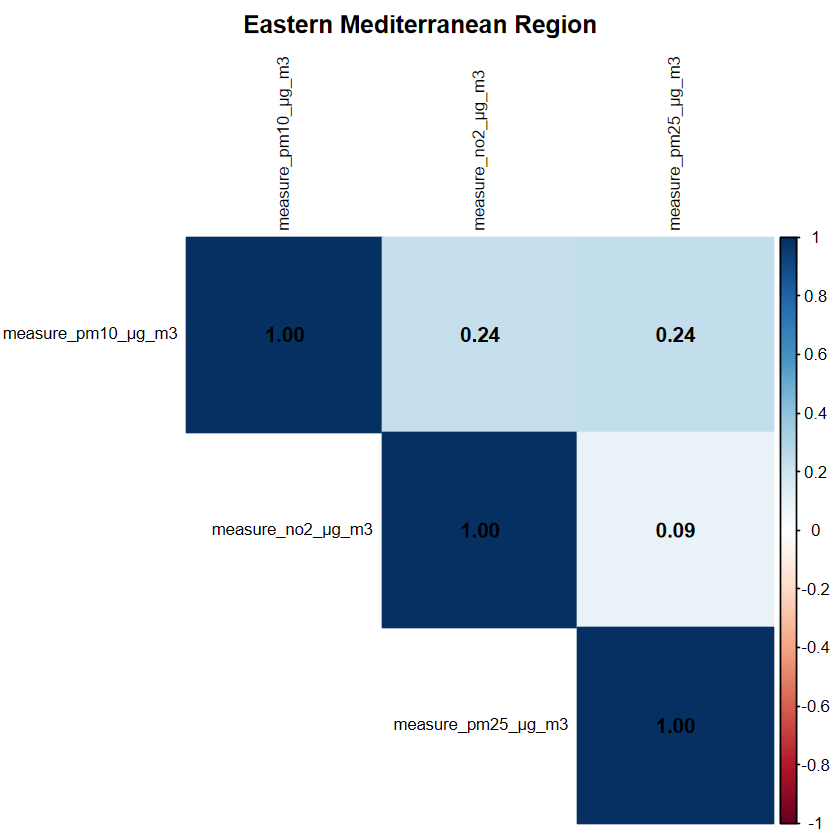


===== Region of the Americas =====
                   measure_pm10_μg_m3 measure_no2_μg_m3 measure_pm25_μg_m3
measure_pm10_μg_m3              1.000             0.486              0.813
measure_no2_μg_m3               0.486             1.000              0.442
measure_pm25_μg_m3              0.813             0.442              1.000


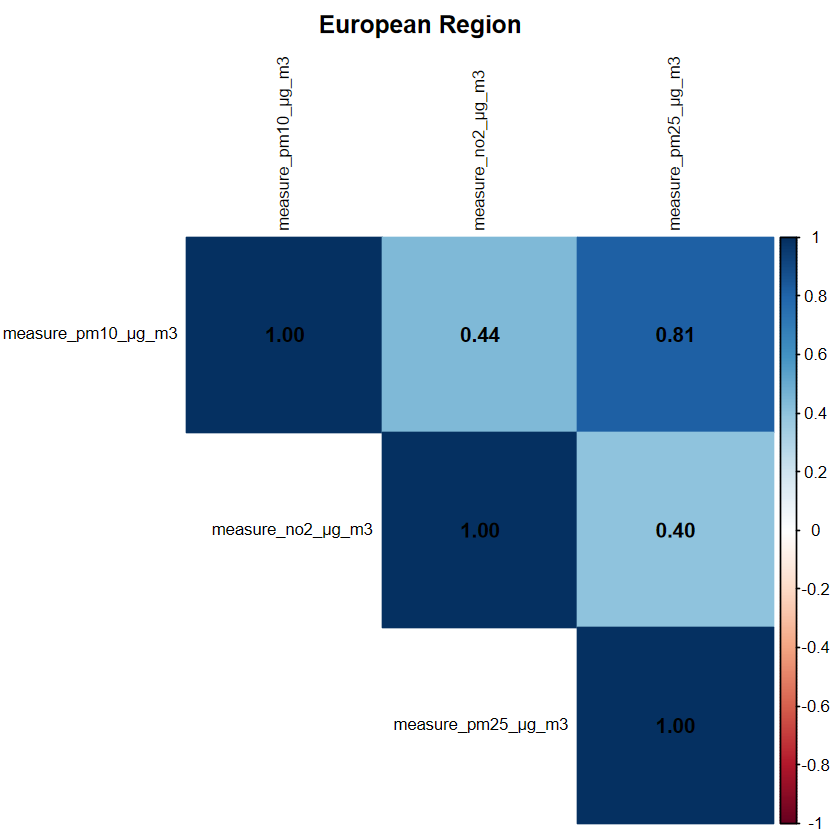


===== Western Pacific Region =====
                   measure_pm10_μg_m3 measure_no2_μg_m3 measure_pm25_μg_m3
measure_pm10_μg_m3              1.000             0.835              0.878
measure_no2_μg_m3               0.835             1.000              0.672
measure_pm25_μg_m3              0.878             0.672              1.000


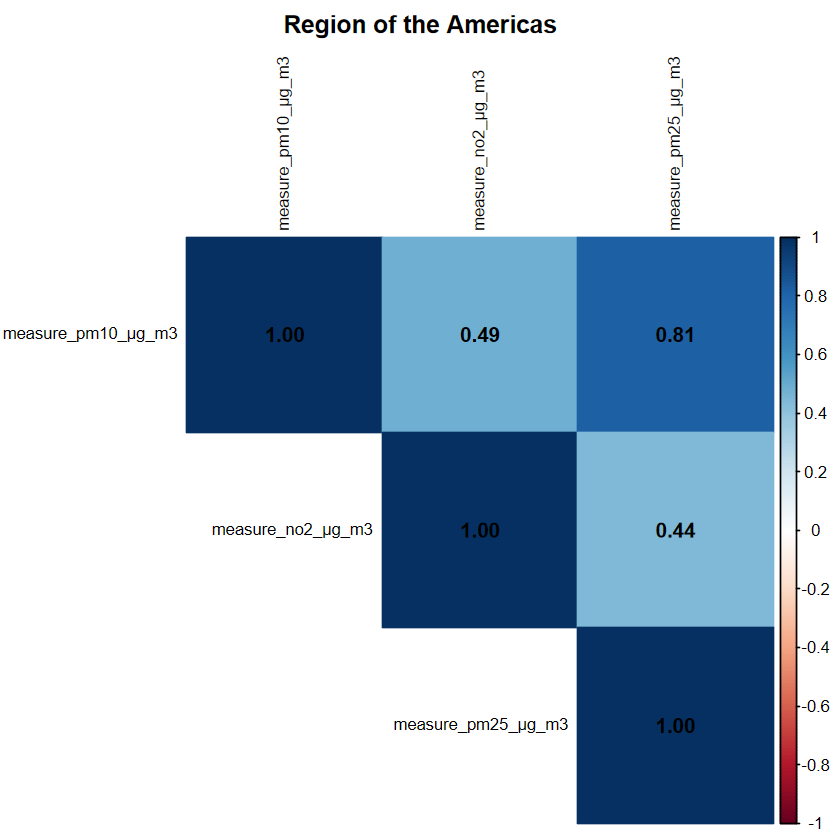


===== South East Asia Region =====
                   measure_pm10_μg_m3 measure_no2_μg_m3 measure_pm25_μg_m3
measure_pm10_μg_m3              1.000             0.564              0.863
measure_no2_μg_m3               0.564             1.000              0.545
measure_pm25_μg_m3              0.863             0.545              1.000


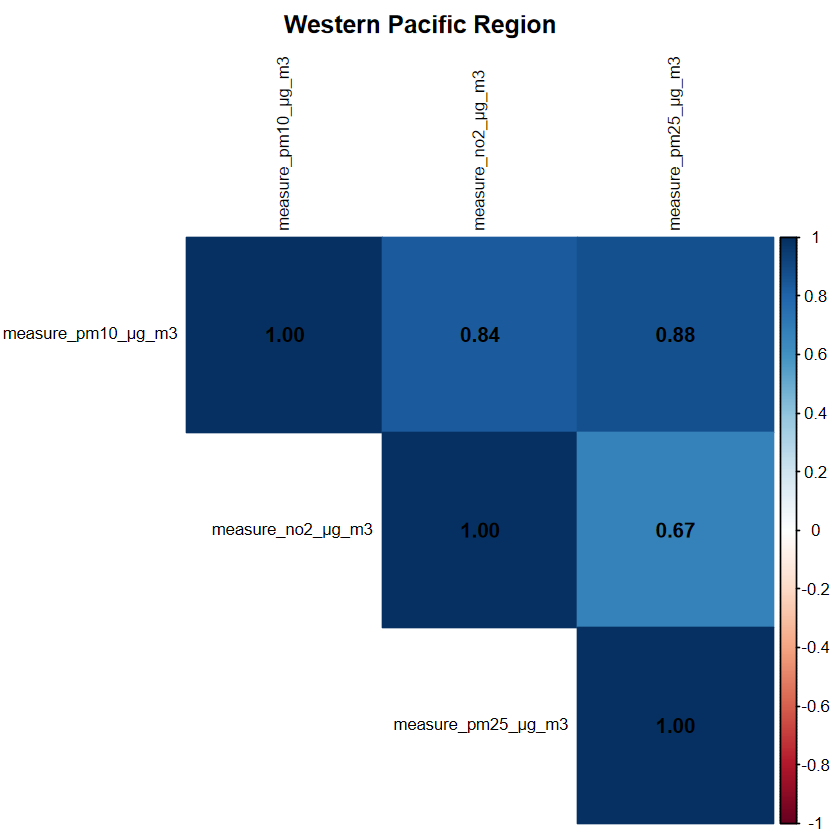


===== African Region =====
                   measure_pm10_μg_m3 measure_no2_μg_m3 measure_pm25_μg_m3
measure_pm10_μg_m3              1.000             0.501              0.747
measure_no2_μg_m3               0.501             1.000              0.449
measure_pm25_μg_m3              0.747             0.449              1.000


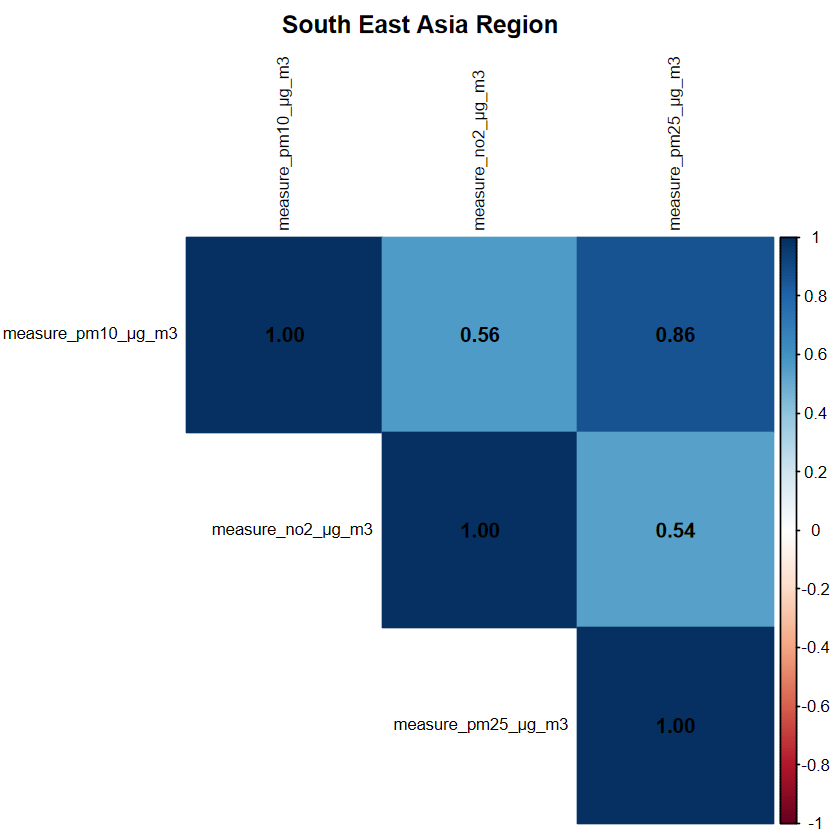

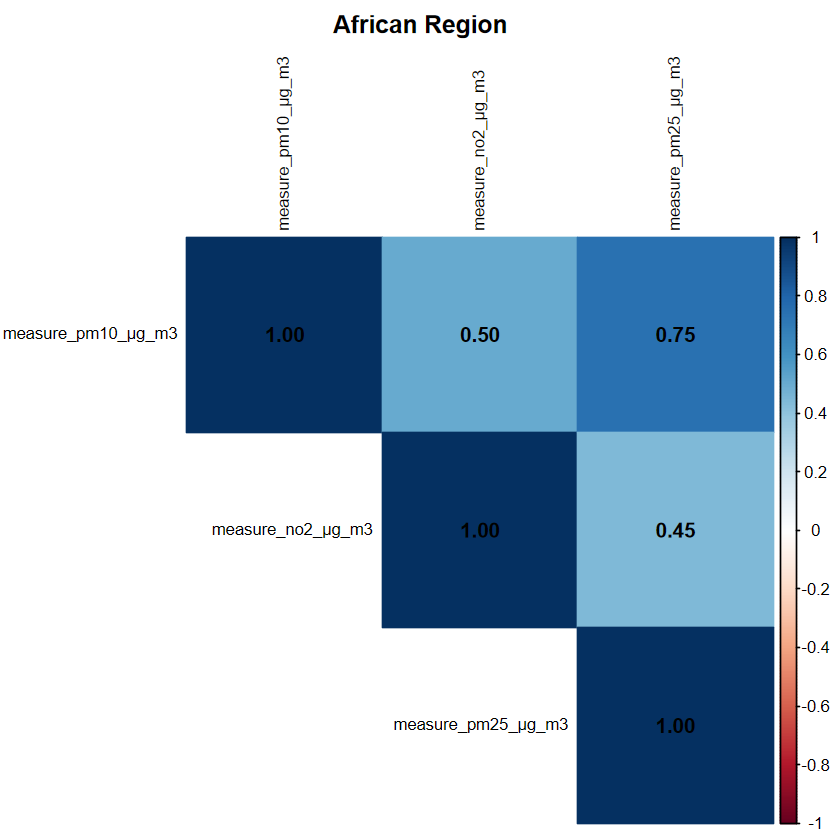

In [34]:
# ====== CORRELATION PAR REGION, année 2019 =====
# Liste des régions
regions <- unique(data$region)

# Boucle pour chaque région
for(region_name in regions) {
 
 # Filtrer les données
 data_region <- subset(data, region == region_name & measure_year == 2019)
 
 if(nrow(data_region) == 0) next
 
 # Sélectionner les polluants et convertir en numérique
 polluants <- data_region[, c("measure_pm10_μg_m3", "measure_no2_μg_m3", "measure_pm25_μg_m3")]
 polluants[] <- lapply(polluants, function(x) as.numeric(as.character(x)))
 
 # Calculer la corrélation
 cor_matrix <- cor(polluants, use = "complete.obs")
 
 # Afficher le nom de la région
 cat("\n=====", region_name, "=====\n")
 print(round(cor_matrix, 3))
 
 # Afficher le graphique
 corrplot(cor_matrix, method = "color", type = "upper", 
          tl.col = "black", addCoef.col = "black", tl.cex = 0.8,
          title = region_name, mar = c(0,0,2,0))
}

Points clés à retenir

Pattern universel : PM10 et PM2.5 sont systématiquement les plus corrélés (particules de tailles similaires)
Région Western Pacific : Corrélations les plus élevées pour tous les polluants → sources communes ou conditions météorologiques similaires
Région Eastern Mediterranean : Corrélations les plus faibles → sources de pollution plus diversifiées ou conditions particulières
NO2 vs particules : Corrélations modérées suggérant des sources partiellement communes (trafic urbain) mais aussi des sources spécifiques
Implications :

Les stratégies de réduction doivent être adaptées par région
Le contrôle d'un polluant peut avoir des effets variables sur les autres selon la région
Les régions à fortes corrélations bénéficieraient de mesures globales
Les régions à faibles corrélations nécessitent des approches ciblées par polluant

## Création des dataset

## Focus sur le continent européen

Nous avons décidé de concentrer notre analyse sur les villes du continent européen pour plusieurs raisons méthodologiques importantes :

**Richesse des données disponibles :** L'Europe demeure l'une des régions les mieux documentées en matière de surveillance de la qualité de l'air, avec un volume de données substantiel et une continuité temporelle qui permet des analyses robustes.

**Couverture territoriale homogène :** Contrairement à d'autres continents où les capteurs de pollution sont concentrés dans quelques zones urbaines spécifiques, l'Europe bénéficie d'une couverture quasi-complète de son territoire par un réseau dense de stations de monitoring. Cette uniformité géographique garantit une représentativité spatiale optimale pour nos analyses.

**Standardisation des mesures :** Les pays européens suivent des protocoles de mesure harmonisés, notamment dans le cadre des directives européennes sur la qualité de l'air, ce qui assure une cohérence et une comparabilité des données entre les différentes villes et pays.

Cette approche nous permet donc de travailler sur un échantillon géographiquement cohérent et statistiquement solide, conditions essentielles pour produire des résultats d'analyse fiables et généralisables à l'échelle continentale.

In [35]:
# Filtrage simple en cascade extraire le nouveau dataset "positive_cities"

#  Sélectionner les villes de la région Europe
villes_europe <- data[data$region == "European Region", ]

# Garder seulement les années 2017 à 2019
villes_europe_periode <- villes_europe[villes_europe$measure_year >= 2017 & 
                                         villes_europe$measure_year <= 2019, ]

# Garder seulement les lignes où PM10 et NO2 ne sont pas vides
positive_cities <- villes_europe_periode[!is.na(villes_europe_periode$measure_pm10_μg_m3) & 
                                           !is.na(villes_europe_periode$measure_no2_μg_m3), ]

# Vérification de la nouvelle base de données
print(paste("Nombre de lignes dans positive_cities :", nrow(positive_cities)))
print(paste("Nombre de villes uniques :", length(unique(positive_cities$city))))
print(paste("Nombre de pays uniques :", length(unique(positive_cities$country_name))))

# Affichage des pays
print("Pays correspondants :")
print(unique(positive_cities$country_name))

[1] "Nombre de lignes dans positive_cities : 5554"
[1] "Nombre de villes uniques : 2062"
[1] "Nombre de pays uniques : 38"
[1] "Pays correspondants :"
 [1] "Andorra"                "Austria"                "Belgium"               
 [4] "Bulgaria"               "Bosnia and Herzegovina" "Switzerland"           
 [7] "Cyprus"                 "Czechia"                "Germany"               
[10] "Denmark"                "Spain"                  "Estonia"               
[13] "Finland"                "France"                 "United Kingdom"        
[16] "Greece"                 "Croatia"                "Hungary"               
[19] "Ireland"                "Iceland"                "Italy"                 
[22] "Lithuania"              "Luxembourg"             "Latvia"                
[25] "Monaco"                 "North Macedonia"        "Malta"                 
[28] "Montenegro"             "Netherlands"            "Norway"                
[31] "Poland"                 "Portugal"         

Objectif : Ce code applique un filtrage en cascade pour extraire un sous-ensemble de données focalisé sur les villes européennes ayant des mesures complètes de qualité de l'air (PM10 et NO2) entre 2017 et 2019. Le processus permet d'obtenir un dataset positive_cities contenant uniquement les observations exploitables pour l'analyse de la pollution atmosphérique en Europe sur cette période spécifique.

### Dataset retenue

## Visualisations et Analyses

###  Valeurs moyennes (KPI)

In [68]:
# Calcul des moyennes
pm25_avg <- round(mean(positive_cities$measure_pm25_μg_m3, na.rm = TRUE), 1)
pm10_avg <- round(mean(positive_cities$measure_pm10_μg_m3, na.rm = TRUE), 1)
no2_avg  <- round(mean(positive_cities$measure_no2_μg_m3, na.rm = TRUE), 1)

# Affichage des résultats
cat("PM2.5 moyen :", pm25_avg, "µg/m³\n")
cat("PM10 moyen  :", pm10_avg, "µg/m³\n") 
cat("NO2 moyen   :", no2_avg, "µg/m³\n")

PM2.5 moyen : 10 µg/m³
PM10 moyen  : 14 µg/m³
NO2 moyen   : 20.7 µg/m³


### Évolution annuelle NO2 et PM10

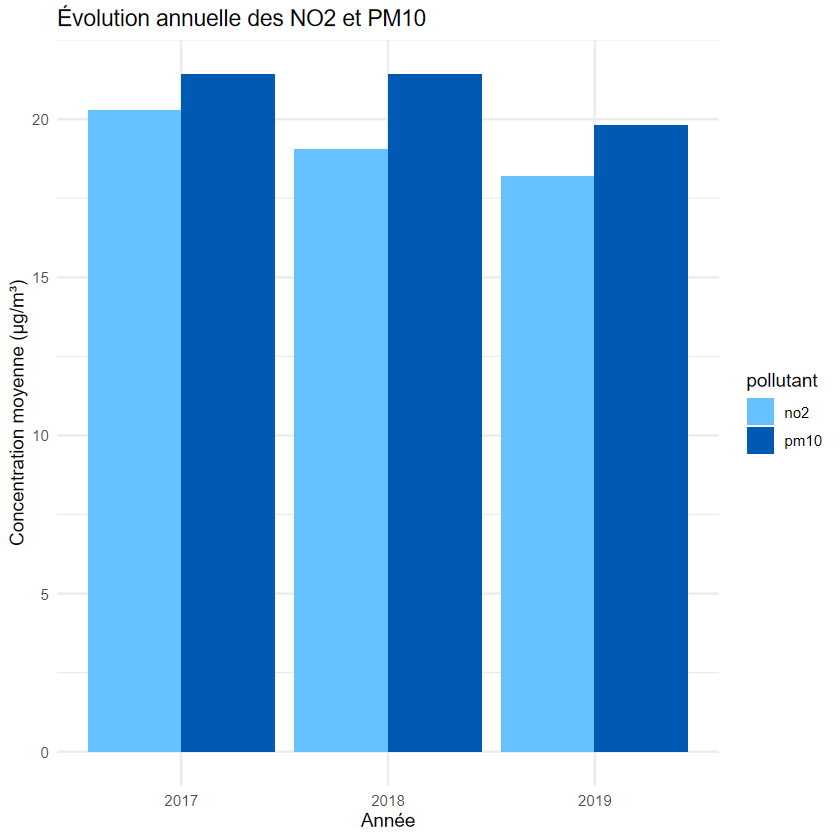

In [38]:
# Vérification et ajustement des noms de colonnes
colnames(positive_cities) <- gsub("μ", "u", colnames(positive_cities))  # Remplace μ par u

# Correction 2: Code original avec juste le changement de μ en u
evolution_df <- positive_cities %>%
  group_by(measure_year) %>%
  summarise(
    no2 = mean(measure_no2_ug_m3, na.rm = TRUE),  # μ remplacé par u
    pm10 = mean(measure_pm10_ug_m3, na.rm = TRUE)  # μ remplacé par u
  ) %>%
  pivot_longer(cols = c("no2", "pm10"), names_to = "pollutant", values_to = "value")

# Le graphique reste identique
ggplot(evolution_df, aes(x = factor(measure_year), y = value, fill = pollutant)) +
  geom_col(position = "dodge") +
  labs(x = "Année", y = "Concentration moyenne (µg/m³)", title = "Évolution annuelle des NO2 et PM10") +
  scale_fill_manual(values = c("no2" = "#66c2ff", "pm10" = "#0059b3")) +
  theme_minimal()


In [ ]:
** Observation des Tendances d'Émissions**

Dans notre analyse récente des données sur la qualité de l'air, nous avons observé une légère baisse des émissions de polluants atmosphériques. Bien que cette diminution soit encourageante et semble indiquer le début d'une tendance positive, elle est actuellement trop faible pour en déduire une tendance de fond significative.

Cette observation suggère que, bien que des efforts aient été déployés pour réduire les émissions, leur impact global reste limité. Il est essentiel de poursuivre et d'intensifier ces efforts pour obtenir des réductions plus substantielles et durables des niveaux de pollution.

Nous continuerons de surveiller ces tendances pour évaluer si cette baisse initiale se transforme en une amélioration significative et constante de la qualité de l'air à long terme.


### Top 5 pays/villes les plus et moins pollués

In [39]:
# Vérification et ajustement des noms de colonnes
colnames(positive_cities) <- gsub("μ", "u", colnames(positive_cities))  # Remplace μ par u

# Top pays pollués
positive_cities %>%
  group_by(country_name) %>%
  summarise(pm10 = mean(measure_pm10_ug_m3, na.rm = TRUE)) %>%
  arrange(desc(pm10)) %>%
  head(5)

# Pays les moins pollués
positive_cities %>%
  group_by(country_name) %>%
  summarise(pm10 = mean(measure_pm10_ug_m3, na.rm = TRUE)) %>%
  arrange(pm10) %>%
  head(5)

# Top villes polluées
positive_cities %>%
  group_by(city) %>%
  summarise(pm10 = mean(measure_pm10_ug_m3, na.rm = TRUE)) %>%
  arrange(desc(pm10)) %>%
  head(5)

# Villes les moins polluées
positive_cities %>%
  group_by(city) %>%
  summarise(pm10 = mean(measure_pm10_ug_m3, na.rm = TRUE)) %>%
  arrange(pm10) %>%
  head(5)


country_name,pm10
<chr>,<dbl>
Montenegro,50.66250
North Macedonia,49.26333
Turkey,47.34073
Bosnia and Herzegovina,44.78923
Serbia,41.55769


country_name,pm10
<chr>,<dbl>
Iceland,9.778636
Estonia,11.422500
Finland,11.813061
Ireland,13.450435
Norway,13.799167


city,pm10
<chr>,<dbl>
Igdir,118.23333
Erzincan,72.98667
Ilidza,72.66000
Hatay,72.41000
Bakırcı Mahallesi,71.98500


city,pm10
<chr>,<dbl>
Jungfraujoch,2.600000
Suðurnesjabær,2.630000
Todalen,2.766667
Muonio,3.170000
Garmisch-Partenkirchen,3.900000


 ### Évolution PM10 & NO2 par pays (exemple : France)

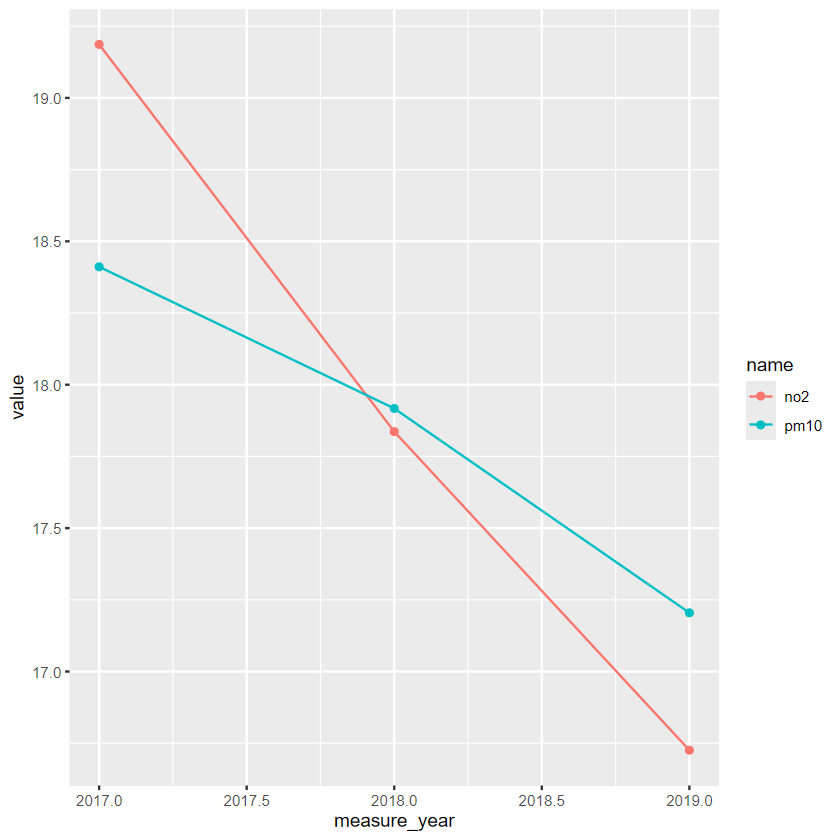

In [40]:
ggplot(
  positive_cities %>% 
    filter(country_name == "France") %>%
    group_by(measure_year) %>%
    summarise(pm10 = mean(measure_pm10_ug_m3, na.rm = TRUE),
              no2 = mean(measure_no2_ug_m3, na.rm = TRUE)) %>%
    pivot_longer(-measure_year),
  aes(measure_year, value, color = name)) +
  geom_line() +
  geom_point()


### Dataset supplémentaire: 

In [41]:
# Filtrage des villes avec stations de monitoring

# Garder seulement les lignes où monitoring_station_number n'est pas vide
positive_cities_stations <- positive_cities[!is.na(positive_cities$monitoring_station_number), ]

print("Pays avec stations de monitoring :")
print(unique(positive_cities_stations$country_name))# Filtrage des villes avec stations de monitoring

# Vérification de la nouvelle base
print(paste("Nombre de lignes après filtrage stations :", nrow(positive_cities_stations)))
print(paste("Nombre de villes avec stations :", length(unique(positive_cities_stations$city))))
print(paste("Nombre de pays avec stations :", length(unique(positive_cities_stations$country_name))))

[1] "Pays avec stations de monitoring :"
[1] "Bulgaria"    "Switzerland" "Cyprus"      "Czechia"     "Estonia"    
[6] "Croatia"     "Lithuania"   "Monaco"      "Malta"      
[1] "Nombre de lignes après filtrage stations : 370"
[1] "Nombre de villes avec stations : 155"
[1] "Nombre de pays avec stations : 9"


In [89]:
# Nettoyage et préparation du dataset
data_clean <- positive_cities_stations %>%
  separate(monitoring_station_number, into = c("number", "type"), sep = " ", extra = "drop", fill = "right") %>%
  filter(!is.na(type)) %>%
  mutate(
    number = as.numeric(number),
    type = gsub(",", "", type),
    type = gsub("-", "", type),
    type = str_to_title(type),
    type = ifelse(type == "Ruralregional", "Rural", type)
  )



## Proportion pour chaque type de zone dans l'emission totale

### Proportion PM10

# A tibble: 7 × 3
  type        moyenne_pm10 proportion
  <chr>              <dbl>      <dbl>
1 Background          13.2       8.44
2 Industrial          17.1      11.0 
3 Residential         34.7      22.2 
4 Rural               21.9      14.0 
5 Suburban            26.2      16.7 
6 Traffic             15.6       9.96
7 Urban               27.7      17.7 


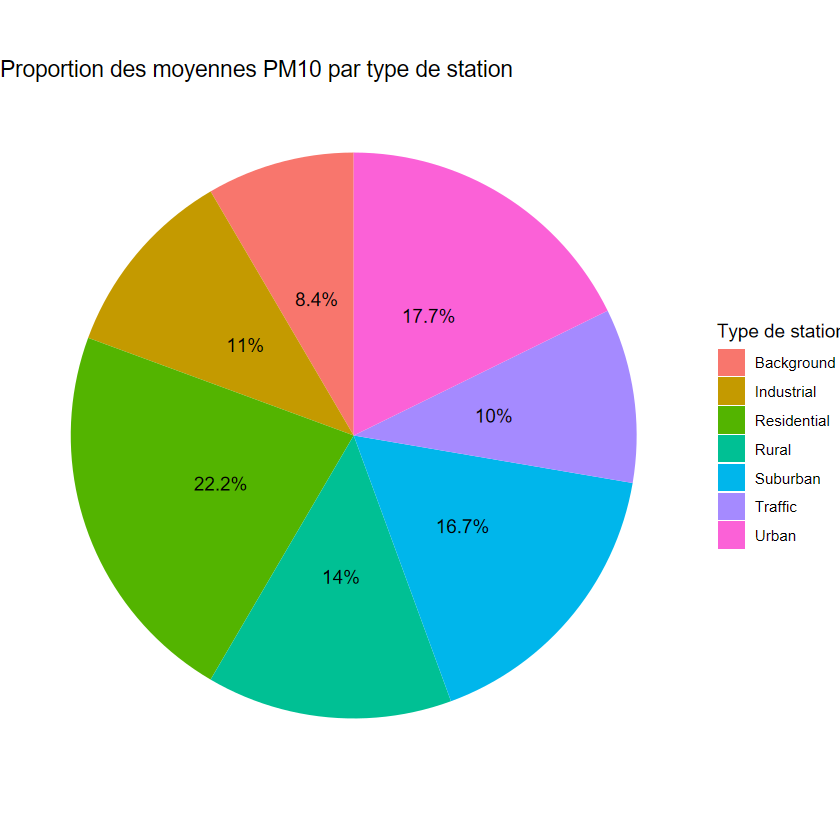

In [86]:
# Création du graphique en camenbert pour PM10

# Calcul des moyennes PM10 par type de station
pm10_moyennes <- data_clean %>%
  group_by(type) %>%
  summarise(moyenne_pm10 = mean(measure_pm10_ug_m3, na.rm = TRUE)) %>%
  mutate(proportion = moyenne_pm10 / sum(moyenne_pm10) * 100)

# Affichage des résultats
print(pm10_moyennes)

# Création du graphique en camembert
ggplot(pm10_moyennes, aes(x = "", y = proportion, fill = type)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar("y", start = 0) +
  labs(title = "Proportion des moyennes PM10 par type de station",
       fill = "Type de station") +
  theme_void() +
  geom_text(aes(label = paste0(round(proportion, 1), "%")), 
            position = position_stack(vjust = 0.5))

**Analyse européenne des types de zones d’émissions de PM10**

Les zones résidentielles présentent les concentrations moyennes les plus élevées de PM10, suivies des zones urbaines et suburbaines. Les zones rurales et industrielles affichent des niveaux modérés, tandis que les zones de trafic et de fond (background) ont les plus faibles concentrations.

Ces résultats indiquent que la pollution aux particules fines ne se limite pas aux zones industrielles ou routières, mais concerne aussi largement les espaces résidentiels et urbains, soulignant la nécessité d’une approche globale pour la réduction des émissions.

### Proportion de NO2

# A tibble: 7 × 3
  type        moyenne_no2 proportion
  <chr>             <dbl>      <dbl>
1 Background        16.7       12.9 
2 Industrial        20.3       15.6 
3 Residential       17.5       13.4 
4 Rural              9.24       7.10
5 Suburban          19.0       14.6 
6 Traffic           27.9       21.5 
7 Urban             19.5       15.0 


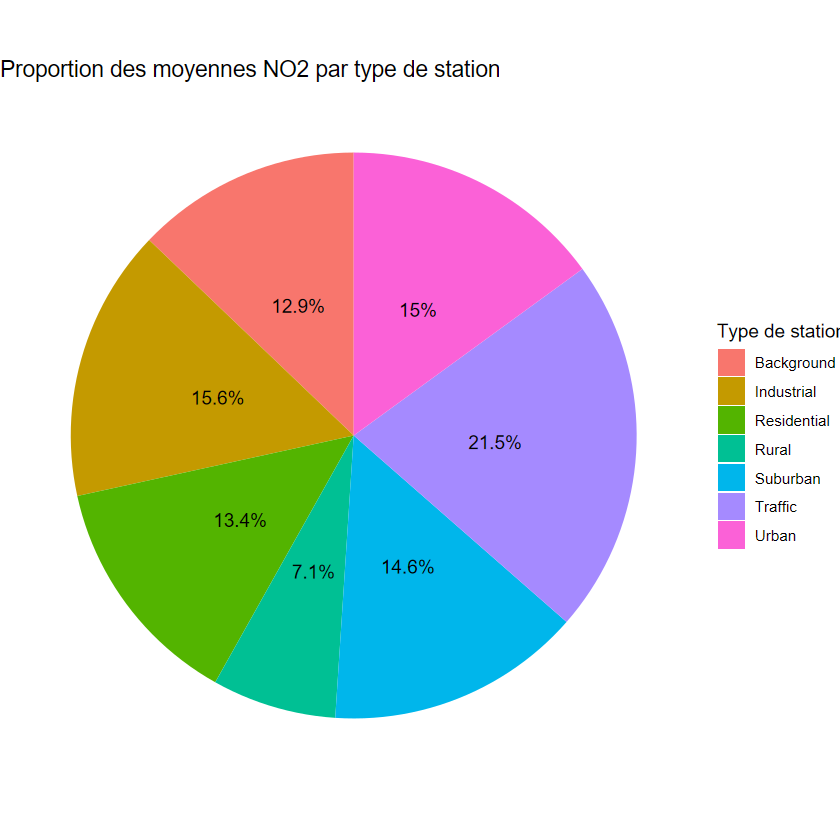

In [57]:
# Création du graphique en camembert pour NO2

# Calcul des moyennes NO2 par type de station
no2_moyennes <- data_clean %>%
  group_by(type) %>%
  summarise(moyenne_no2 = mean(measure_no2_ug_m3, na.rm = TRUE)) %>%
  mutate(proportion = moyenne_no2 / sum(moyenne_no2) * 100)

# Affichage des résultats
print(no2_moyennes)

# Création du graphique en camembert
library(ggplot2)

ggplot(no2_moyennes, aes(x = "", y = proportion, fill = type)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar("y", start = 0) +
  labs(title = "Proportion des moyennes NO2 par type de station",
       fill = "Type de station") +
  theme_void() +
  geom_text(aes(label = paste0(round(proportion, 1), "%")),
            position = position_stack(vjust = 0.5))

**Analyse européenne des émissions de NO₂ selon le type de zone**
Les zones de trafic concentrent les niveaux les plus élevés de NO₂, suivies des zones industrielles, urbaines et suburbaines. Les zones résidentielles et de fond affichent des concentrations modérées, tandis que les zones rurales ont les niveaux les plus faibles.

Ces données confirment l’impact majeur du trafic routier sur la pollution au NO₂, tout en soulignant la contribution significative des activités industrielles et urbaines.

### Le cas de la suisse

Ce code filtre les données pour ne retenir que les villes suisses entre 2016 et 2020, où les mesures de PM10 et NO₂ sont disponibles, puis visualise l’évolution annuelle moyenne de ces polluants. La Suisse a été choisie car elle est le seul pays européen à avoir réalisé des relevés exhaustifs sur cette période, avec une couverture complète du territoire et une large diversité de zones d’émission, garantissant ainsi une analyse représentative.

Nombre de lignes dans positive_cities : 461 


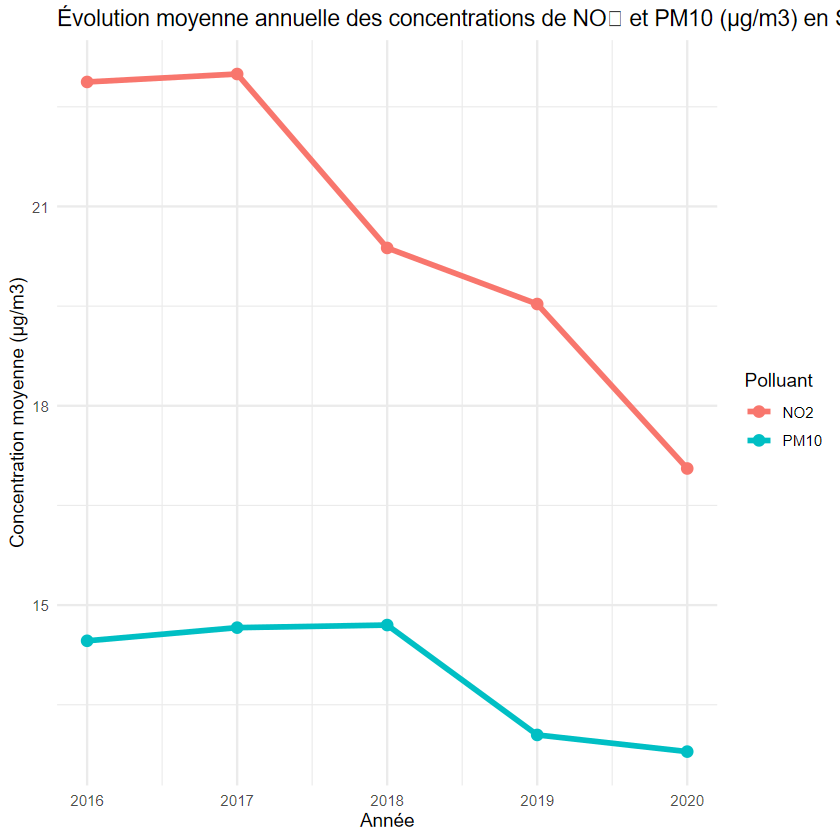

In [66]:
#  Filtrage


# Sélectionner les villes de la Suisse
villes_europe <- data[data$country_name == "Switzerland", ]

# Garder seulement les années 2016 à 2020
villes_europe_periode <- villes_europe[villes_europe$measure_year >= 2016 &
                                       villes_europe$measure_year <= 2020, ]

# Garder seulement les lignes où PM10 et NO2 ne sont pas vides
positive_cities <- villes_europe_periode[!is.na(villes_europe_periode$measure_pm10_μg_m3) &
                                         !is.na(villes_europe_periode$measure_no2_μg_m3), ]

# Vérification
cat("Nombre de lignes dans positive_cities :", nrow(positive_cities), "\n")



# Préparation des données pour ggplot

# Conversion au format long
positive_long <- positive_cities %>%
  select(city, measure_year, NO2 = measure_no2_μg_m3, PM10 = measure_pm10_μg_m3) %>%
  pivot_longer(cols = c(NO2, PM10),
               names_to = "Pollutant",
               values_to = "Value")

#  Visualisation de l’évolution moyenne par année


ggplot(positive_long, aes(x = measure_year, y = Value, color = Pollutant)) +
  stat_summary(fun = mean, geom = "line", linewidth = 1.2) +  # Remplacer size par linewidth
  stat_summary(fun = mean, geom = "point", size = 2.5) +  # size est toujours utilisé pour les points
  labs(
    title = "Évolution moyenne annuelle des concentrations de NO₂ et PM10 (μg/m3) en Suisse",
    x = "Année",
    y = "Concentration moyenne (μg/m3)",
    color = "Polluant"
  ) +
  theme_minimal()

### Analyse des Émissions en Suisse 

**Observation :**
La Suisse a connu une baisse forte et constante des émissions entre 2017 et 2019, contrastant avec les tendances observées dans le reste de l'Europe.

**Facteurs Contribuant à la Réduction des Émissions :**

- **Politiques Environnementales Strictes :** Réglementations rigoureuses pour les véhicules, les industries et les centrales électriques.
- **Promotion des Énergies Renouvelables :** Investissements significatifs dans l'hydroélectricité, l'énergie solaire et éolienne.
- **Transport Public et Mobilité Durable :** Réseau de transport public efficace et promotion de la mobilité douce.
- **Innovation Technologique :** Adoption de technologies propres dans divers secteurs.
- **Sensibilisation et Éducation :** Campagnes de sensibilisation pour modifier les comportements des citoyens et des entreprises.
- **Accords Internationaux :** Participation active à des accords internationaux sur le climat.
- **Taxes et Incitations Financières :** Mécanismes financiers pour encourager les comportements respectueux de l'environnement.


## Conclusion

Cette étude révèle des tendances significatives dans l'évolution de la qualité de l'air en Europe entre 2017 et 2019, mettant en lumière des disparités régionales et l'efficacité des politiques environnementales. La Suisse, en particulier, se distingue par une réduction marquée des émissions de polluants atmosphériques, grâce à des politiques environnementales strictes, une transition vers les énergies renouvelables, et un système de transport public robuste.

Les résultats montrent que les zones résidentielles et urbaines sont les plus touchées par la pollution aux particules fines (PM10), tandis que les zones de trafic sont les plus affectées par les émissions de dioxyde d'azote (NO₂). Cela souligne l'importance d'adopter une approche intégrée pour réduire les émissions, ciblant non seulement les sources industrielles, mais aussi les zones résidentielles et les infrastructures de transport.

Pour améliorer la qualité de l'air à l'échelle mondiale, nous recommandons :

Gouvernance Mondiale des Données : Standardiser la collecte et la gestion des données sur la qualité de l'air pour assurer la cohérence et la comparabilité des informations.

Application des Politiques de Réduction des Émissions : Adopter des politiques environnementales strictes et promouvoir les énergies renouvelables.

Collaboration Internationale : Faciliter la coopération entre les pays pour partager les meilleures pratiques et innovations technologiques.

In [ ]:
# 1. Sources PM2.5
plot_ly(
  data.frame(
    Source = c("Résidentiel", "Transports", "Industrie", "Agriculture", "Électricité", "Autres"),
    Valeur = c(38, 18, 14, 14, 5, 11)
  ),
  labels = ~Source, values = ~Valeur, type = 'pie'
) %>% layout(title = "Sources PM2.5")
# 2. Sources NO2
plot_ly(
  data.frame(
    Source = c("Transports", "Industrie", "Énergie", "Résidentiel"),
    Valeur = c(58, 22, 14, 6)
  ),
  labels = ~Source, values = ~Valeur, type = 'pie'
) %>% layout(title = "Sources NO2")
# 3. Composition PM
plot_ly(
  data.frame(
    Composant = c("PM1.0", "Autres"),
    Valeur = c(72.5, 27.5)
  ),
  labels = ~Composant, values = ~Valeur, type = 'pie'
) %>% layout(title = "Composition PM2.5")